# VIX Trend

## Contents

- [Configuration](#configuration)
- [Market Data](#market-data)
- [Trend Indicators](#trend-indicators)
- [Chart](#chart)
- [Slide](#slide)
- [Video Script](#video-script)
- [Video](#video)

## Configuration
[top](#contents)

In [1]:
from pydantic import BaseModel


class VixTechnical(BaseModel):
    name: str
    trading_day: str
    interval: str
    high: str
    low: str
    close: str
    change_percent: str
    change_text: str
    trend: str
    level: str
    interpretation: str

## Market Data
[top](#contents)

In [ ]:
import yfinance as yf
import pandas as pd


def get_vix_data(start: str, end: str) -> pd.DataFrame:
    # Define the ticker symbol for the S&P 500 index
    ticker = "^VIX"

    # Download historical data
    df = yf.download(ticker, start=start, end=end, interval="1d", auto_adjust=True)

    # Flatten multi-index columns
    if isinstance(df.columns, pd.MultiIndex):
        column_names = ["Date"] + df.columns.get_level_values(0).tolist()
        df = df.reset_index()
        df.columns = column_names
        df = df.set_index("Date")

    # round to two decimal
    df[["Open", "High", "Low", "Close"]] = df[["Open", "High", "Low", "Close"]].round(2)

    # Save to CSV
    df.to_csv("../output/data/vix/prices.csv")
    print("Data saved to ../output/data/vix/prices.csv")

    return df

In [3]:
from utils.date import get_start_and_end
from utils.data import compute_percent_change

start, end = get_start_and_end()
df = get_vix_data(start, end)
compute_percent_change(df)
df.tail()

[*********************100%***********************]  1 of 1 completed


Data saved to data/vix/prices.csv


,Close,High,Low,Open,Volume,Change%
Date,,,,,,
2025-07-21,16.65,16.99,16.30,16.87,0,1.462523
2025-07-22,16.50,17.48,16.43,16.75,0,-0.900901
2025-07-23,15.37,16.32,15.32,16.23,0,-6.848485
2025-07-24,15.39,15.54,14.95,15.39,0,0.130124
2025-07-25,15.06,15.39,15.00,15.33,0,-2.144250


In [4]:
df.tail()

,Close,High,Low,Open,Volume,Change%
Date,,,,,,
2025-07-21,16.65,16.99,16.30,16.87,0,1.462523
2025-07-22,16.50,17.48,16.43,16.75,0,-0.900901
2025-07-23,15.37,16.32,15.32,16.23,0,-6.848485
2025-07-24,15.39,15.54,14.95,15.39,0,0.130124
2025-07-25,15.06,15.39,15.00,15.33,0,-2.144250


## Trend Indicators
[top](#contents)

Identify volatility trend whether it is moving up or down.

In [5]:
import pandas as pd
import yfinance as yf


def calc_indicators(df):
    # Calculate EMA
    df["EMA10"] = df["Close"].ewm(span=10, adjust=False).mean()

    # Calculate slope as first difference
    df["EMA10_slope"] = df["EMA10"].diff()

    # Identify up/down slope direction
    df["Signal"] = df["EMA10_slope"].apply(lambda x: 1 if x > 0 else -1 if x < 0 else 0)
    df["Trend"] = df["EMA10_slope"].apply(
        lambda x: "Up" if x > 0 else "Down" if x < 0 else "Flat"
    )

In [6]:
calc_indicators(df)

How to intrepret absolute level of VIX value:

In [7]:
def interpret_vix_en(vix_value):
    if vix_value < 12:
        return "Very low volatility: Extreme calm, potential overconfidence"
    elif 12 <= vix_value < 16:
        return "Low volatility: Optimistic, stable market sentiment"
    elif 16 <= vix_value < 20:
        return "Normal volatility: Neutral, mildly cautious"
    elif 20 <= vix_value < 25:
        return "Moderately high volatility: Growing nervousness"
    elif 25 <= vix_value < 30:
        return "High volatility: Increased uncertainty, cautious sentiment"
    elif 30 <= vix_value < 40:
        return "Very high volatility: Risk-off, anxious markets"
    else:
        return "Extreme volatility: Panic or crisis conditions"

In [8]:
def interpret_vix_zh(vix_value):
    if vix_value < 12:
        return "极低波动率：市场极度平静，可能过度自信"
    elif 12 <= vix_value < 16:
        return "低波动率：乐观情绪，市场较为稳定"
    elif 16 <= vix_value < 20:
        return "正常波动率：情绪中性，略显谨慎"
    elif 20 <= vix_value < 25:
        return "中高波动率：市场开始紧张"
    elif 25 <= vix_value < 30:
        return "高波动率：不确定性升高，情绪趋于保守"
    elif 30 <= vix_value < 40:
        return "非常高波动率：风险厌恶情绪浓厚，市场焦虑"
    else:
        return "极端波动率：恐慌或危机状态"

In [9]:
# Show the last few rows
df.tail()

,Close,High,Low,Open,Volume,Change%,EMA10,EMA10_slope,Signal,Trend
Date,,,,,,,,,,
2025-07-21,16.65,16.99,16.30,16.87,0,1.462523,16.763325,-0.025183,-1,Down
2025-07-22,16.50,17.48,16.43,16.75,0,-0.900901,16.715448,-0.047877,-1,Down
2025-07-23,15.37,16.32,15.32,16.23,0,-6.848485,16.470821,-0.244627,-1,Down
2025-07-24,15.39,15.54,14.95,15.39,0,0.130124,16.274308,-0.196513,-1,Down
2025-07-25,15.06,15.39,15.00,15.33,0,-2.144250,16.053525,-0.220783,-1,Down


## Chart
[top](#contents)

In [ ]:
import mplfinance as mpf


def create_chart(df):

    # Create additional plots
    addplot = [
        mpf.make_addplot(df["EMA10"], color="orange", width=1.2),  # overlay EMA10
    ]

    # Define VIX interpretation levels
    vix_levels = [
        (0, 12, "Very Low", "gray"),
        (12, 16, "Low", "green"),
        (16, 20, "Normal", "lime"),
        (20, 25, "Mod High", "orange"),
        (25, 30, "High", "red"),
        (30, 40, "Very High", "maroon"),
        (40, 100, "Extreme", "black"),
    ]

    hlines = dict(
        hlines=[20, 30],
        colors=["green", "red"],
        linestyle=["--", "--"],
        linewidths=[1, 1],
    )

    mpf.plot(
        df,
        type="ohlc",
        hlines=hlines,
        addplot=addplot,
        volume=False,
        style="charles",
        figsize=(15, 8),
        tight_layout=True,
        xrotation=0,
        datetime_format="%Y-%m-%d",
        savefig=dict(fname="../output/data/vix/chart.svg", dpi=120),
    )
    mpf.plot(
        df,
        type="ohlc",
        hlines=hlines,
        addplot=addplot,
        volume=False,
        style="charles",
        figratio=(16, 9),
        xrotation=0,
        datetime_format="%Y-%m-%d",
    )

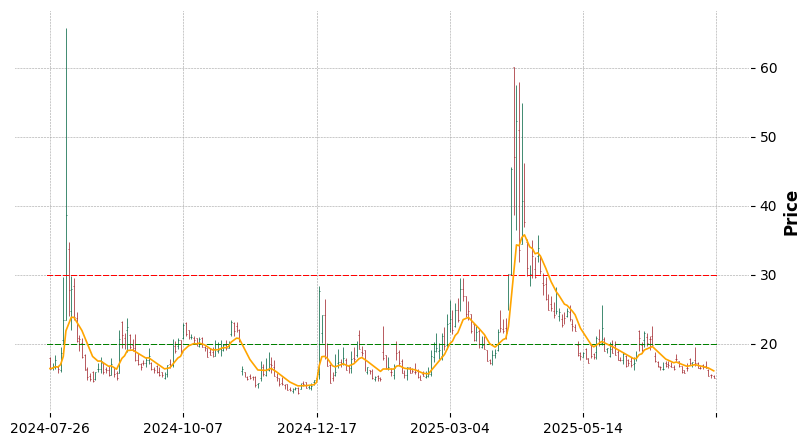

In [11]:
create_chart(df)

In [ ]:
from utils.chart import add_symbol_to_svg

add_symbol_to_svg("../output/data/vix/chart.svg", "恐慌指数")

## Video Script
[top](#contents)

🎙️**【VIX波动率指数每日市场更新】**

今天我们来看看VIX——也就是大家熟悉的“恐慌指数”，它是衡量市场情绪和预期波动的重要指标。

截至最新交易日收盘，VIX指数报 [填入数值]，相比前一日 [上涨/下跌]了[填入点数]点，目前呈现出一个 [上升/下降] 的趋势。

📈 如果你不太熟悉VIX，这里简单科普一下：

一般来说，VIX在 20以下 代表市场相对平静，投资人信心充足；

介于 20到30之间 时，市场开始出现波动，投资者开始警惕；

一旦 突破30甚至更高，那通常意味着市场恐慌上升、避险情绪强烈。

🧠 那我们该怎么解读当前的VIX水平呢？
现在的VIX在 [填入当前区间，例如“低于20”]，说明市场整体情绪仍然 [填入解读，例如“乐观、风险偏好较高”]。不过，考虑到近期有 [可选：通胀数据、FOMC会议等事件]，接下来波动率可能出现变化，投资人需要密切关注。

💡小提醒：VIX并不能直接告诉你市场涨跌，但它可以揭示市场是否“紧张”，是我们判断风险情绪的重要参考。

In [15]:
def get_vix_change_text(change_percent):
    if change_percent > 0:
        text = f"较前一日上涨了{change_percent:.2f}% "
    elif change_percent < 0:
        text = f"较前一日下跌了{abs(change_percent):.2f}% "
    else:
        text = ""
    return text

In [16]:
def get_vix_level(value):
    """区间文字用于脚本中"""
    if value < 12:
        return "极低区间"
    elif value < 16:
        return "偏低区间"
    elif value < 20:
        return "正常区间"
    elif value < 25:
        return "略高区间"
    elif value < 30:
        return "较高区间"
    elif value < 40:
        return "很高区间"
    else:
        return "极高区间"

In [17]:
def get_vix_interpretation(value):
    if value < 12:  # 波动率极低
        return "市场情绪非常平静，可能略显过度乐观"
    elif value < 16:  # 波动率偏低
        return "市场整体乐观，风险偏好较高"
    elif value < 20:  # 波动率属于正常区间
        return "市场情绪中性，略带观望"  # 表示中性市场情绪
    elif value < 25:  # 波动率略高
        return "投资人开始转为谨慎"
    elif value < 30:  # 波动率较高
        return "市场不确定性加剧，避险情绪上升"
    elif value < 40:  # 波动率很高
        return "市场情绪紧张，明显偏向风险规避"
    else:  # 波动率极高
        return "市场恐慌加剧，可能处于危机状态"

In [18]:
def get_trend(trend):
    if trend == "Up":
        return "上升"
    elif trend == "Down":
        return "下降"
    else:
        return "持平"

In [19]:
def vix_video_script(c: VixTechnical) -> str:
    """
    恐慌指数报[填入数值]，相比前一日[上涨/下跌]了[填入点数]点，
    目前呈现出一个[上升/下降]的趋势。
    从当前水平来看，属于[填入当前区间]，
    说明市场整体情绪[填入解读，例如“乐观、风险偏好较高”]。
    """
    script = f"""
恐慌指数报{c.close}，{c.change_text}，目前呈现出一个{c.trend}的趋势。
从当前水平来看，属于{c.level}，{c.interpretation}。
"""
    return script.strip()

In [20]:
last = df.iloc[-1]
change_pct = last["Change%"]

data = {
    "name": "恐慌指数（VIX）",
    "trading_day": last.name.strftime("%Y-%m-%d"),
    "interval": "1d",
    "high": "{:.2f}".format(last["High"]),
    "low": "{:.2f}".format(last["Low"]),
    "close": "{:.2f}".format(last["Close"]),
    "change_percent": "{:.2f}%".format(last["Change%"]),
    "change_text": get_vix_change_text(change_pct),
    "trend": get_trend(last["Trend"]),
    "level": get_vix_level(last["Close"]),
    "interpretation": get_vix_interpretation(last["Close"]),
}

In [21]:
data

{'name': '恐慌指数（VIX）',
 'trading_day': '2025-07-25',
 'interval': '1d',
 'high': '15.39',
 'low': '15.00',
 'close': '15.06',
 'change_percent': '-2.14%',
 'change_text': '较前一日下跌了2.14% ',
 'trend': '下降',
 'level': '偏低区间',
 'interpretation': '市场整体乐观，风险偏好较高'}

In [ ]:
from utils.script import save_script, save_technical

c = VixTechnical(**data)
script = vix_video_script(c)

filejson = "../output/data/vix/technical.json"
save_technical(c, filejson)

filename = "../output/data/vix/script.txt"
save_script(script, filename)

print(script)

恐慌指数报15.06，较前一日下跌了2.14% ，目前呈现出一个下降的趋势。
从当前水平来看，属于偏低区间，市场整体乐观，风险偏好较高。


恐慌指数报16.32，相比前一日下跌了0.27点，目前维持下降的趋势。
从当前水平来看，属于正常区间，市场情绪中性，略带观望。